<a href="https://colab.research.google.com/github/yuva0567890/23mid0421APAassignment3/blob/main/23MID0421APAassess3dataset1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
print("K N Yuvaraj")
print("23MID0421")

K N Yuvaraj
23MID0421


In [2]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install tensorflow
!pip install nltk
!pip install openai

In [3]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

import warnings
warnings.filterwarnings("ignore")

In [4]:
# ==========================================
# Load Dataset 1
# ==========================================

spam = pd.read_csv("spam.csv", encoding="latin-1")

spam.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# ==========================================
# Keep Required Columns Only
# ==========================================

spam = spam[['v1','v2']]

spam.columns = ['label','text']

spam.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
# ==========================================
# Dataset Information
# ==========================================

spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
# ==========================================
# Missing Values
# ==========================================

spam.isnull().sum()

,0
label,0
text,0


In [8]:
# ==========================================
# Class Distribution
# ==========================================

spam['label'].value_counts()

,count
label,
ham,4825
spam,747


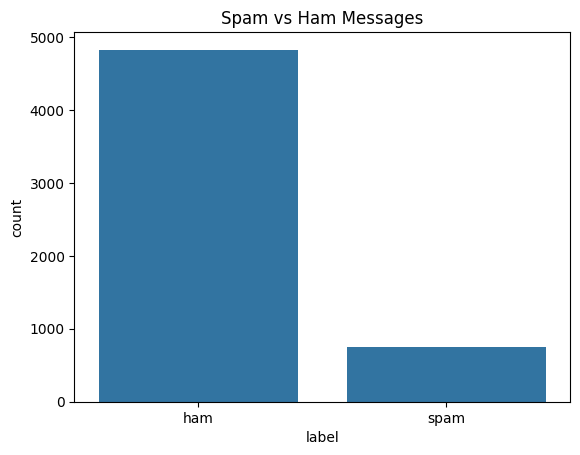

In [9]:
# ==========================================
# Plot Class Distribution
# ==========================================

sns.countplot(x='label', data=spam)

plt.title("Spam vs Ham Messages")

plt.show()

In [10]:
# ==========================================
# Convert Labels into Numbers
# ham = 0
# spam = 1
# ==========================================

encoder = LabelEncoder()

spam['label'] = encoder.fit_transform(spam['label'])

spam.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# ==========================================
# Separate Features and Labels
# ==========================================

X = spam['text']

y = spam['label']

In [12]:
# ==========================================
# Split Dataset
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [13]:
# ==========================================
# Dataset Shapes
# ==========================================

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (4457,)
Testing Samples : (1115,)


In [14]:
# ==========================================
# Convert Text into TF-IDF Features
# ==========================================

tfidf = TfidfVectorizer(

    stop_words='english',

    max_features=5000

)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(4457, 5000)
(1115, 5000)


In [15]:
#MODEL 1 : NAIVE BAYES
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [16]:
# ==========================================
# Predict using Naive Bayes
# ==========================================

nb_pred = nb_model.predict(X_test_tfidf)

In [17]:
# ==========================================
# Naive Bayes Accuracy
# ==========================================

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy :", round(nb_accuracy*100,2),"%")

Naive Bayes Accuracy : 97.22 %


In [18]:
# ==========================================
# Naive Bayes Classification Report
# ==========================================

print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [19]:
# ==========================================
# Naive Bayes Confusion Matrix
# ==========================================

nb_cm = confusion_matrix(y_test, nb_pred)

print(nb_cm)

[[965   1]
 [ 30 119]]


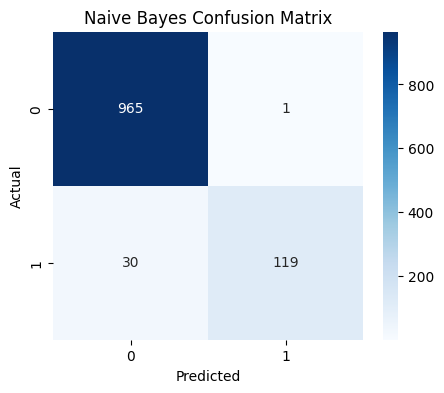

In [20]:
# ==========================================
# Plot Naive Bayes Confusion Matrix
# ==========================================

plt.figure(figsize=(5,4))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [21]:
# MODEL 2 : K-NEAREST NEIGHBOR
# ==========================================
# Train KNN Model
# ==========================================

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [22]:
# ==========================================
# Predict using KNN
# ==========================================

knn_pred = knn_model.predict(X_test_tfidf)

In [23]:
# ==========================================
# KNN Accuracy
# ==========================================

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", round(knn_accuracy*100,2),"%")

KNN Accuracy : 91.84 %


In [24]:
# ==========================================
# KNN Classification Report
# ==========================================

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.96       966
           1       1.00      0.39      0.56       149

    accuracy                           0.92      1115
   macro avg       0.96      0.69      0.76      1115
weighted avg       0.93      0.92      0.90      1115



In [25]:
# ==========================================
# KNN Confusion Matrix
# ==========================================

knn_cm = confusion_matrix(y_test, knn_pred)

print(knn_cm)

[[966   0]
 [ 91  58]]


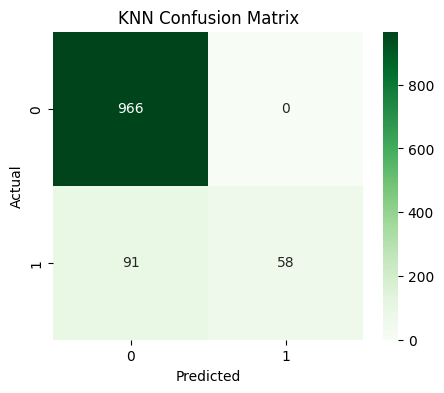

In [26]:
# ==========================================
# Plot KNN Confusion Matrix
# ==========================================

plt.figure(figsize=(5,4))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [27]:
# MODEL COMPARISON
# ==========================================
# Compare Model Accuracy
# ==========================================

comparison = pd.DataFrame({

    "Model":[

        "Naive Bayes",

        "KNN"

    ],

    "Accuracy":[

        nb_accuracy,

        knn_accuracy

    ]

})

comparison

,Model,Accuracy
0,Naive Bayes,0.972197
1,KNN,0.918386


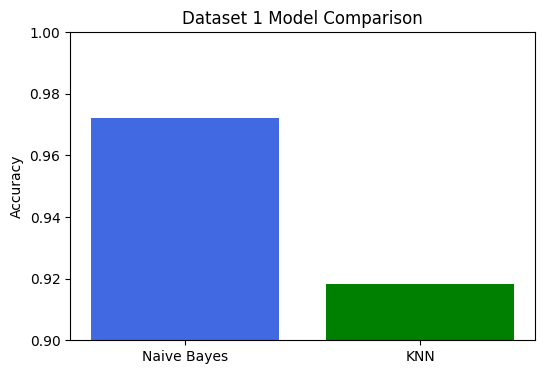

In [28]:
# ==========================================
# Accuracy Comparison Graph
# ==========================================

plt.figure(figsize=(6,4))

plt.bar(

    comparison["Model"],

    comparison["Accuracy"],

    color=["royalblue","green"]

)

plt.ylim(0.90,1.00)

plt.title("Dataset 1 Model Comparison")

plt.ylabel("Accuracy")

plt.show()

In [29]:
# ==========================================
# Display Best Model
# ==========================================

best_model = comparison.sort_values(

    by="Accuracy",

    ascending=False

)

print(best_model)

         Model  Accuracy
0  Naive Bayes  0.972197
1          KNN  0.918386


In [30]:
# DEEP LEARNING MODEL BILSTM
# ==========================================
# Tokenize Text
# ==========================================

max_words = 5000
max_length = 100

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)


In [31]:
# ==========================================
# Convert Text into Sequences
# ==========================================

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [32]:
# ==========================================
# Padding Sequences
# ==========================================

X_train_pad = pad_sequences(

    X_train_seq,

    maxlen=max_length,

    padding='post'

)

X_test_pad = pad_sequences(

    X_test_seq,

    maxlen=max_length,

    padding='post'

)

print(X_train_pad.shape)

print(X_test_pad.shape)

(4457, 100)
(1115, 100)


In [33]:
# ==========================================
# Build BiLSTM Model
# ==========================================

model = Sequential()

model.add(

    Embedding(

        input_dim=max_words,

        output_dim=128,

        input_length=max_length

    )

)

model.add(

    Bidirectional(

        LSTM(64)

    )

)

model.add(

    Dropout(0.5)

)

model.add(

    Dense(

        1,

        activation='sigmoid'

    )

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [34]:
# ==========================================
# Compile Model
# ==========================================

model.compile(

    loss='binary_crossentropy',

    optimizer='adam',

    metrics=['accuracy']

)

In [35]:
# ==========================================
# Train BiLSTM Model
# ==========================================

history = model.fit(

    X_train_pad,

    y_train,

    epochs=5,

    batch_size=32,

    validation_split=0.2,

    verbose=1

)

Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.9234 - loss: 0.2068 - val_accuracy: 0.9709 - val_loss: 0.0900
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9874 - loss: 0.0500 - val_accuracy: 0.9809 - val_loss: 0.0747
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.9916 - loss: 0.0360 - val_accuracy: 0.9652 - val_loss: 0.1201
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.9972 - loss: 0.0148 - val_accuracy: 0.9877 - val_loss: 0.0544
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9978 - loss: 0.0073 - val_accuracy: 0.9865 - val_loss: 0.0825


In [36]:
# ==========================================
# Evaluate BiLSTM Model
# ==========================================

loss, lstm_accuracy = model.evaluate(

    X_test_pad,

    y_test

)

print("BiLSTM Accuracy :", round(lstm_accuracy*100,2),"%")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9821 - loss: 0.0825
BiLSTM Accuracy : 98.21 %


In [37]:
# ==========================================
# Predict using BiLSTM
# ==========================================

prediction = model.predict(X_test_pad)

prediction = (prediction > 0.5).astype(int)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [38]:
# ==========================================
# BiLSTM Classification Report
# ==========================================

print(classification_report(

    y_test,

    prediction

))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [39]:
# ==========================================
# BiLSTM Confusion Matrix
# ==========================================

cm = confusion_matrix(

    y_test,

    prediction

)

print(cm)




[[965   1]
 [ 19 130]]


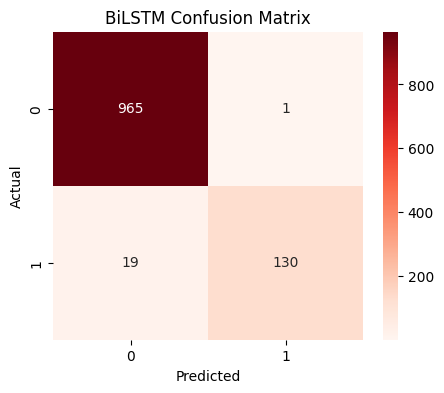

In [40]:
# ==========================================
# Plot BiLSTM Confusion Matrix
# ==========================================

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Reds'

)

plt.title("BiLSTM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [41]:
# ==========================================
# Compare All Models
# ==========================================

final_result = pd.DataFrame({

    "Model":[

        "Naive Bayes",

        "KNN",

        "BiLSTM"

    ],

    "Accuracy":[

        nb_accuracy,

        knn_accuracy,

        lstm_accuracy

    ]

})

final_result

,Model,Accuracy
0,Naive Bayes,0.972197
1,KNN,0.918386
2,BiLSTM,0.982063


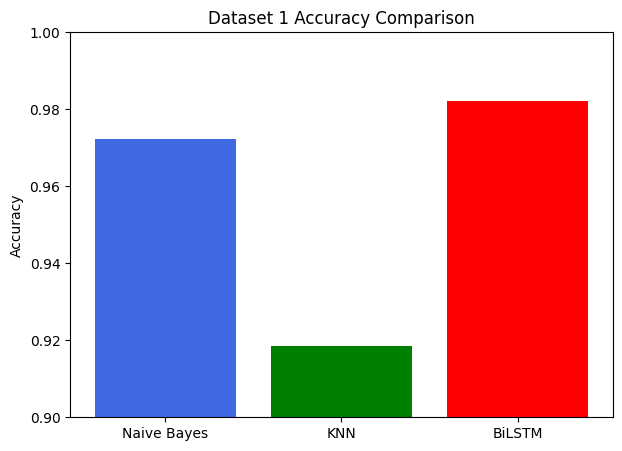

In [42]:
# ==========================================
# Accuracy Comparison Graph
# ==========================================

plt.figure(figsize=(7,5))

plt.bar(

    final_result["Model"],

    final_result["Accuracy"],

    color=["royalblue","green","red"]

)

plt.title("Dataset 1 Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.90,1.00)

plt.show()

In [43]:
# ==========================================
# Save BiLSTM Model
# ==========================================

model.save("dataset1_bilstm_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


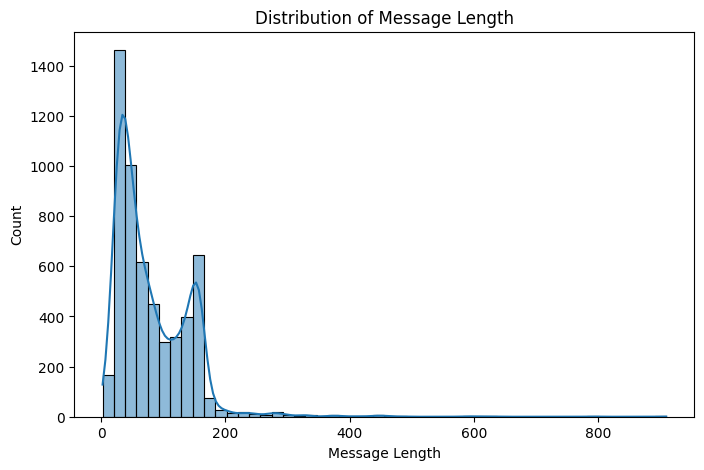

In [44]:
# ==========================================
# Message Length Distribution
# ==========================================

spam['message_length'] = spam['text'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    data=spam,
    x='message_length',
    bins=50,
    kde=True
)

plt.title("Distribution of Message Length")

plt.xlabel("Message Length")

plt.ylabel("Count")

plt.show()

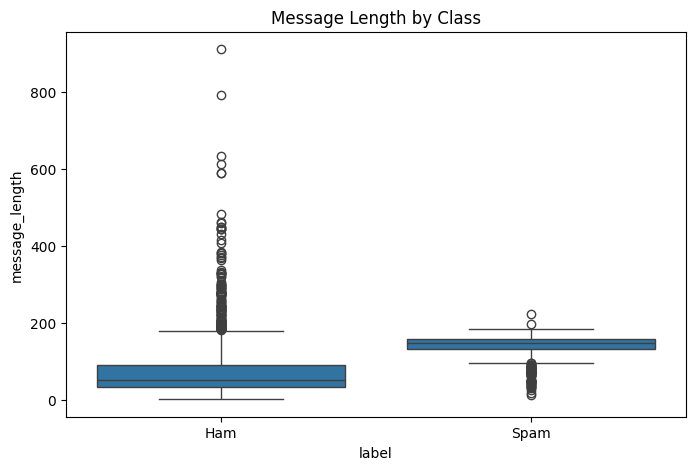

In [45]:
# ==========================================
# Message Length by Class
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='message_length',
    data=spam
)

plt.xticks([0,1],["Ham","Spam"])

plt.title("Message Length by Class")

plt.show()

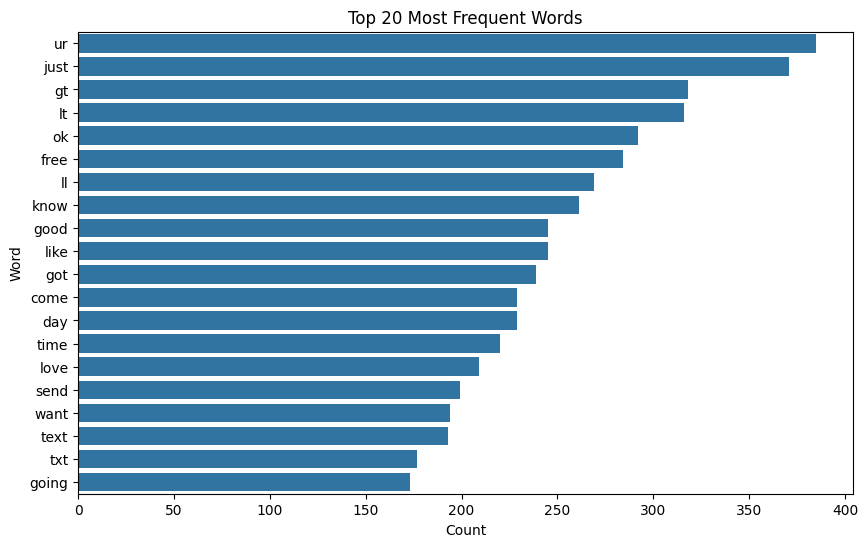

In [46]:
# ==========================================
# Top 20 Frequent Words
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_words = cv.fit_transform(spam['text'])

word_counts = np.asarray(X_words.sum(axis=0)).flatten()

words = cv.get_feature_names_out()

word_df = pd.DataFrame({

    "Word":words,

    "Count":word_counts

})

word_df = word_df.sort_values(

    by="Count",

    ascending=False

)

plt.figure(figsize=(10,6))

sns.barplot(
    data=word_df,
    x="Count",
    y="Word"
)

plt.title("Top 20 Most Frequent Words")

plt.show()

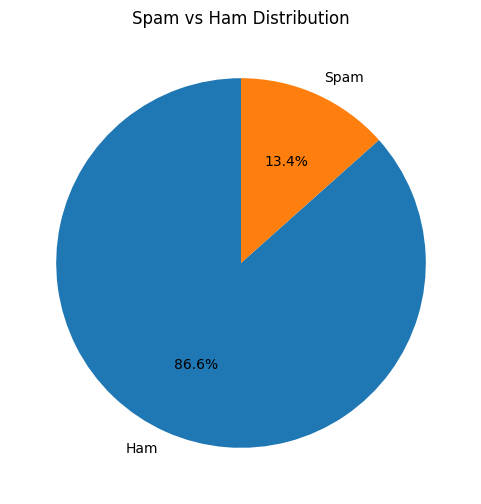

In [47]:
# ==========================================
# Spam vs Ham Percentage
# ==========================================

counts = spam['label'].value_counts()

labels = ['Ham','Spam']

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Spam vs Ham Distribution")

plt.show()

In [48]:
!pip install wordcloud

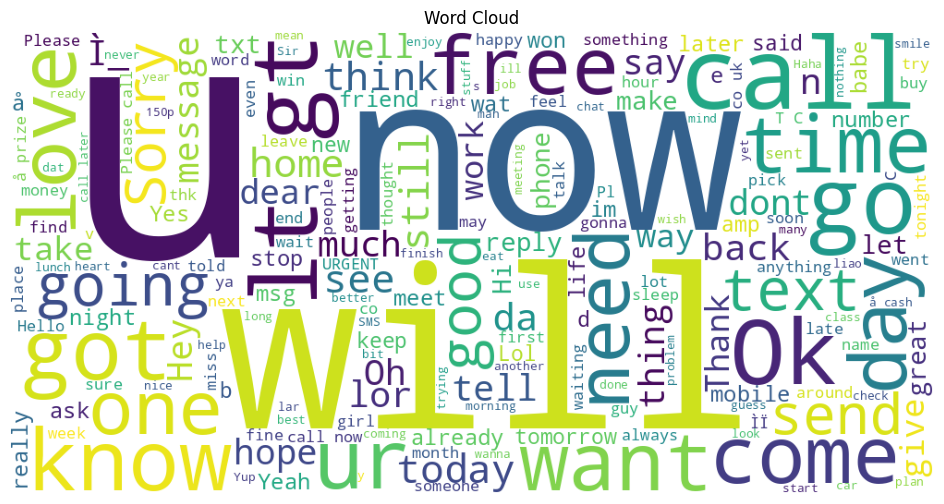

In [49]:
# ==========================================
# Word Cloud
# ==========================================

from wordcloud import WordCloud

text = " ".join(spam["text"])

wc = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis("off")

plt.title("Word Cloud")

plt.show()